Imports & Setup

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Hyperparameters

In [27]:
batch_size = 64
learning_rate = 0.001
epochs = 10

Load & Preprocess Fashion MNIST

In [28]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

baseline model

In [29]:
class DeepFNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.fc4(x)

Training & Evaluation Functions

In [30]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return correct / total


Train Baseline Model

In [31]:
model = DeepFNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Test Acc: {test_acc:.4f}")

Epoch [1/10] Loss: 0.5056 Train Acc: 0.8151 Test Acc: 0.8409
Epoch [2/10] Loss: 0.3713 Train Acc: 0.8638 Test Acc: 0.8447
Epoch [3/10] Loss: 0.3305 Train Acc: 0.8780 Test Acc: 0.8623
Epoch [4/10] Loss: 0.3063 Train Acc: 0.8864 Test Acc: 0.8622
Epoch [5/10] Loss: 0.2845 Train Acc: 0.8945 Test Acc: 0.8595
Epoch [6/10] Loss: 0.2701 Train Acc: 0.8996 Test Acc: 0.8808
Epoch [7/10] Loss: 0.2526 Train Acc: 0.9055 Test Acc: 0.8814
Epoch [8/10] Loss: 0.2399 Train Acc: 0.9095 Test Acc: 0.8785
Epoch [9/10] Loss: 0.2271 Train Acc: 0.9140 Test Acc: 0.8783
Epoch [10/10] Loss: 0.2177 Train Acc: 0.9173 Test Acc: 0.8866


Flexible Experimental Model

In [32]:
class ExperimentalFNN(nn.Module):
    def __init__(self, hidden_layers, activation):
        super().__init__()
        layers = []
        in_features = 28 * 28

        for h in hidden_layers:
            layers.append(nn.Linear(in_features, h))
            layers.append(activation)
            in_features = h

        layers.append(nn.Linear(in_features, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

Depth & Width

In [33]:
depth_configs = {
    "1-layer": [256],
    "3-layer": [512, 256, 128],
    "5-layer": [512, 512, 256, 128, 64]
}

print("\nDepth & Width Study")
for name, layers in depth_configs.items():
    model = ExperimentalFNN(layers, nn.ReLU()).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    start = time.time()
    for _ in range(epochs):
        train(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)
    end = time.time()

    print(f"{name} | Test Acc: {test_acc:.4f} | Time: {end-start:.2f}s")


Depth & Width Study
1-layer | Test Acc: 0.8701 | Time: 163.35s
3-layer | Test Acc: 0.8852 | Time: 230.50s
5-layer | Test Acc: 0.8717 | Time: 298.76s


Activation Function Study

In [34]:
activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(0.01)
}

print("\nActivation Function Study")
for name, act in activations.items():
    model = ExperimentalFNN([512, 256, 128], act).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    start = time.time()
    for _ in range(epochs):
        train(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)
    end = time.time()

    print(f"{name} | Test Acc: {test_acc:.4f} | Time: {end-start:.2f}s")


Activation Function Study
Sigmoid | Test Acc: 0.8777 | Time: 205.25s
Tanh | Test Acc: 0.8623 | Time: 210.08s
ReLU | Test Acc: 0.8812 | Time: 231.00s
LeakyReLU | Test Acc: 0.8808 | Time: 203.26s


Hidden Layer Activation Visualization

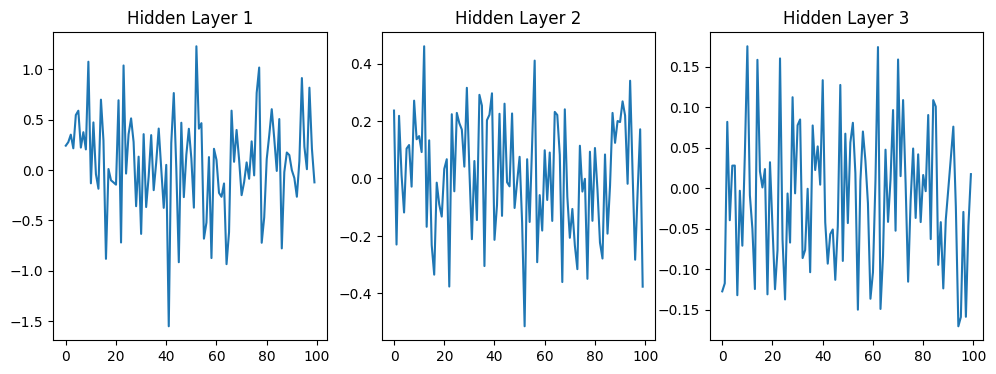

In [35]:
def get_activations(model, image):
    activations = []
    x = image.view(1, -1).to(device)

    for layer in model.net:
        x = layer(x)
        if isinstance(layer, nn.Linear):
            activations.append(x.detach().cpu())

    return activations


# Visualize for one sample
image, label = test_dataset[0]
model = ExperimentalFNN([512, 256, 128], nn.ReLU()).to(device)
activations = get_activations(model, image)

plt.figure(figsize=(12,4))
for i, act in enumerate(activations[:-1]):
    plt.subplot(1, 3, i+1)
    plt.plot(act[0][:100])
    plt.title(f"Hidden Layer {i+1}")
plt.show()